# 02 - Walk-Forward Backtest

Runs the country allocation + monthly-rebalance backtest engine (SPEC.md
sections 9-10) over the walk-forward test fold from `01_global_country_model.ipynb`,
under all four cost scenarios, and reports gross/net portfolio metrics
(SPEC.md section 11) plus country attribution.

This is an **out-of-sample test-fold result on real bounded data** - not a
claim of achieved production performance. See README for the deferred
full-history multi-fold production command.

In [1]:
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from frtbot.config import load_markets_config, load_research_config
from frtbot.data.cache import DataCache
from frtbot.data.providers import get_provider
from frtbot.data.fx import align_fx_to_index, fetch_fx_series, identity_fx_series, to_thb_price
from frtbot.data.quality import detect_extreme_return_days
from frtbot.features.build import MarketSeries, build_country_feature_panel
from frtbot.labels.country import country_classification_label, country_regression_label
from frtbot.models.dataset import build_country_dataset, select_dates
from frtbot.backtest.splits import generate_walk_forward_folds
from frtbot.models.tree import TreeModel
from frtbot.models.mlp import MLPModel
from frtbot.models.trend import TransparentTrendModel
from frtbot.models.ensemble import combine_ensemble
from frtbot.portfolio.construction import construct_country_weights
from frtbot.backtest.engine import cash_daily_return_series, monthly_rebalance_dates, run_all_cost_scenarios
from frtbot.reporting.metrics import country_attribution, summarize_all_scenarios
from frtbot.seed import set_global_seed

pd.set_option("display.width", 140)
set_global_seed(42)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "configs").exists():
    REPO_ROOT = REPO_ROOT.parent

START = date(2012, 6, 1)
END = date(2026, 7, 31)

markets_config = load_markets_config(REPO_ROOT / "configs" / "markets.example.yml")
research_config = load_research_config(REPO_ROOT / "configs" / "research.yml")
cache = DataCache(root=REPO_ROOT / "data")
provider = get_provider("yfinance")

In [2]:
market_series: dict[str, MarketSeries] = {}
for m in markets_config.markets:
    df, _ = cache.get_or_fetch(m.key, m.provider_symbol, "ohlcv", provider, START, END)

    # Data-quality gate (SPEC.md section 3): exclude markets with an implausible single-day
    # move - see notebook 00's audit, which flags this same check. Discovered in practice:
    # 1306.T (JP) has a two-day misadjustment (likely an unadjusted stock split) in the
    # upstream Yahoo Finance feed; including it corrupts volatility/return calculations.
    anomalies = detect_extreme_return_days(df["close"])
    if len(anomalies) > 0:
        print(f"EXCLUDING {m.key} ({m.provider_symbol}): price anomaly on {[d.date() for d in anomalies]}")
        continue

    if m.fx_pair is None:
        fx_aligned = identity_fx_series(df.index)
    else:
        fx_entry = markets_config.fx_for(m)
        rate, _ = fetch_fx_series(fx_entry, cache, provider, START, END)
        fx_aligned = align_fx_to_index(rate, df.index)
    market_series[m.key] = MarketSeries(key=m.key, ohlcv=df, fx_rate_aligned=fx_aligned)

print(f"Usable markets after data-quality gate: {sorted(market_series.keys())}")

panel = build_country_feature_panel(market_series)
thb_close = {k: to_thb_price(s.ohlcv["close"], s.fx_rate_aligned) for k, s in market_series.items()}
thb_daily_return = {k: c.pct_change() for k, c in thb_close.items()}

reg_labels = {
    k: country_regression_label(c, research_config.cash_annual_rate, research_config.horizon_trading_days)
    for k, c in thb_close.items()
}
clf_labels = {k: country_classification_label(v) for k, v in reg_labels.items()}
long_df = build_country_dataset(panel, reg_labels, clf_labels)

all_dates = long_df.index.get_level_values("date").unique()
folds = generate_walk_forward_folds(all_dates, research_config.walk_forward)
fold = folds[0]
train_df = select_dates(long_df, fold.train_dates)
val_df = select_dates(long_df, fold.val_dates)
test_df = select_dates(long_df, fold.test_dates)
print(f"Test fold: {fold.test_dates.min().date()} .. {fold.test_dates.max().date()} ({len(fold.test_dates)} trading days)")

EXCLUDING JP (1306.T): price anomaly on [datetime.date(2015, 1, 5), datetime.date(2026, 3, 30), datetime.date(2026, 4, 1)]
Usable markets after data-quality gate: ['CN', 'EU', 'TH', 'US']


Test fold: 2022-06-01 .. 2023-05-31 (261 trading days)


## Train the ensemble models on the fold and build monthly target weights

In [3]:
models = {
    "tree": TreeModel(seed=research_config.seed),
    "mlp": MLPModel(seed=research_config.seed),
    "transparent_trend": TransparentTrendModel(),
}
test_scores = {}
for name, model in models.items():
    model.fit(train_df, val_df)
    test_scores[name] = model.predict(test_df)

ensemble_result = combine_ensemble(test_scores, research_config.ensemble)
tree_predicted_return = test_scores["tree"]  # eligibility gate uses the tree model's native return-scale prediction

rebalance_dates = monthly_rebalance_dates(fold.test_dates)
vol_63 = {k: panel[k]["vol_63d"] for k in panel}

target_weights = {}
for d in rebalance_dates:
    if d not in ensemble_result.score.index.get_level_values("date"):
        continue
    day_scores = ensemble_result.score.xs(d, level="date")
    day_pred = tree_predicted_return.xs(d, level="date")
    day_vol = pd.Series({k: vol_63[k].get(d, float("nan")) for k in vol_63})
    target_weights[d] = construct_country_weights(day_scores, day_pred, day_vol, research_config.portfolio)

print(f"{len(target_weights)} monthly rebalances in the test fold")
pd.DataFrame(target_weights).T.fillna(0.0).round(3)

12 monthly rebalances in the test fold


,CN,EU,TH,US
2022-06-30,0.336,0.000,0.400,0.264
2022-07-29,0.400,0.347,0.000,0.253
2022-08-31,0.363,0.000,0.400,0.237
2022-09-30,0.326,0.274,0.400,0.000
2022-10-31,0.382,0.367,0.000,0.251
2022-11-30,0.343,0.400,0.000,0.257
2022-12-30,0.263,0.337,0.400,0.000
2023-01-31,0.323,0.000,0.400,0.277
2023-02-28,0.275,0.325,0.400,0.000
2023-03-31,0.365,0.341,0.000,0.294


## Backtest under all four cost scenarios (SPEC.md section 10)

In [4]:
cash_ret = cash_daily_return_series(fold.test_dates, research_config.cash_annual_rate)
results = run_all_cost_scenarios(
    fold.test_dates, target_weights, thb_daily_return, cash_ret, markets_config, research_config.costs
)

summary = summarize_all_scenarios(results, risk_free_daily=cash_ret.iloc[0])
summary_cols = [
    "scenario", "cagr_net", "cumulative_return_net", "annualized_vol_net", "sharpe_net",
    "sortino_net", "max_drawdown_net", "total_turnover", "n_rebalances", "cost_drag",
]
summary[summary_cols]

,scenario,cagr_net,cumulative_return_net,annualized_vol_net,sharpe_net,sortino_net,max_drawdown_net,total_turnover,n_rebalances,cost_drag
0,zero,-0.060610,-0.062706,0.108549,-0.636161,-1.067711,-0.118142,7.605471,11,0.000000
1,optimistic,-0.064041,-0.066251,0.108424,-0.670755,-1.124489,-0.119101,7.605471,11,0.003545
2,base,-0.067461,-0.069784,0.108312,-0.705348,-1.181132,-0.120255,7.605471,11,0.007079
3,severe,-0.077653,-0.080312,0.108050,-0.809002,-1.350061,-0.127037,7.605471,11,0.017607


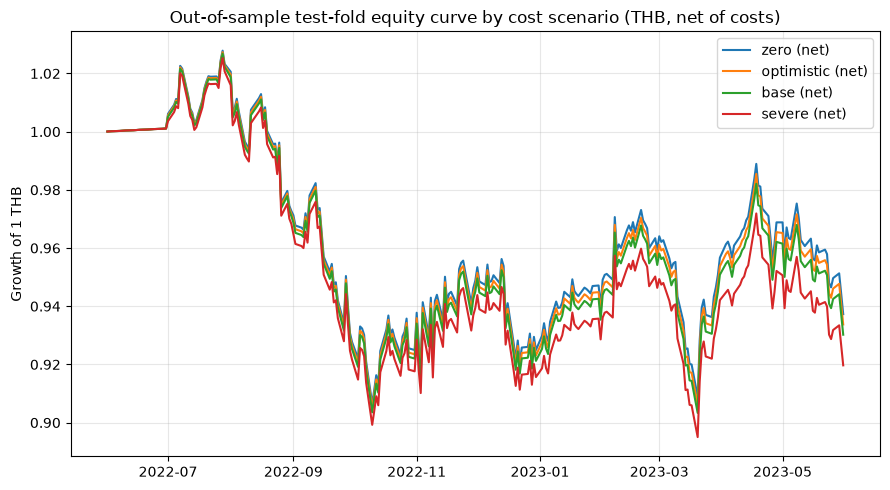

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for scenario, result in results.items():
    equity = (1 + result.daily_net_return).cumprod()
    ax.plot(equity.index, equity.values, label=f"{scenario} (net)")
ax.set_title("Out-of-sample test-fold equity curve by cost scenario (THB, net of costs)")
ax.set_ylabel("Growth of 1 THB")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Country attribution (base cost scenario)

In [6]:
attribution = country_attribution(results["base"].daily_weights, thb_daily_return)
attribution.to_frame("gross_return_contribution")

,gross_return_contribution
EU,0.013800
US,0.003268
TH,-0.001986
CN,-0.074821


## Limitations of this run

- Single walk-forward fold shown inline; see `folds` above for how many the
  bounded 2012-2026 real-data sample actually supports, and README for the
  exact command to run every fold end-to-end.
- Execution timing approximates "next tradable bar" as the next full
  close-to-close return rather than modeling intraday open-price execution
  (see `frtbot.backtest.engine` module docstring).
- `cash_annual_rate` is a documented flat-rate assumption, not a downloaded
  market series (see `configs/research.yml`).
- Five country proxies only - stock-level universes are M3, not this POC.